# Categorização de corredores — KMeans

Comparamos três formas de clusterizar atletas (k=3), cada uma com **duas features** agregadas por atleta:

1. **Distância + pace** — perfil de corrida (volume por treino e velocidade)
2. **FC + distância** — intensidade cardiovascular vs distância percorrida
3. **Distância + frequência semanal** — volume por treino vs regularidade de treinos


In [1]:
%matplotlib inline

import importlib
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl

root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from dataset.analise import carregar_dataset
from dataset.categorizar.kmeans import treina_kmeans, treina_kmeans_por_genero
from dataset.categorizar.tabela_fichas import tabela_fichas
from dataset.categorizar import visualizacao_fichas
from dataset.categorizar.visualizacao_fichas import (
    montar_fichas_atletas,
    plotar_ficha_atleta,
    plotar_fichas_atletas,
)
importlib.reload(visualizacao_fichas)
from dataset.constants import (
    COL_ATHLETE,
    COL_CLUSTER_CORREDOR,
    COL_DISTANCE,
    COL_FREQUENCIA,
    COL_GENDER,
    COL_HR,
    COL_N_CORRIDAS,
    COL_PACE,
)
from dataset.preprocessamento import formatar_delta_pace, formatar_pace, preprocessar


In [3]:
df_raw = carregar_dataset(root / "dataset/raw-data-kaggle.csv")
df = preprocessar(df_raw)

print(f"Corridas: {df.height} | Atletas: {df[COL_ATHLETE].n_unique()}")


Corridas: 40534 | Atletas: 114


## Comparação das combinações de features

Testamos **três pares de variáveis** com KMeans (k=3) para decidir qual combinação usar na categorização final:

| # | Combinação | O que separa |
|---|------------|--------------|
| 1 | Distância + pace | Perfil de corrida (volume por treino × velocidade) |
| 2 | FC + distância | Intensidade cardiovascular × distância |
| 3 | Distância + frequência | Volume por treino × regularidade semanal |

Critérios para escolher: **silhouette**, equilíbrio entre clusters e **interpretabilidade** do perfil de corredor.



1. Distância + pace
Features: ['distance (m)', 'pace_min_km']
Inércia: 101.9799
Silhouette: 0.3947
Davies-Bouldin: 0.9319
Calinski-Harabasz: 68.5833
Atletas clusterizados: 114
Contagem por cluster:
shape: (3, 2)
┌──────────────────┬─────────┐
│ cluster_corredor ┆ atletas │
│ ---              ┆ ---     │
│ i32              ┆ u32     │
╞══════════════════╪═════════╡
│ 0                ┆ 21      │
│ 1                ┆ 70      │
│ 2                ┆ 23      │
└──────────────────┴─────────┘
Centros (escala original):
  cluster_0: dist=7.68 km | pace=5:16/km
  cluster_1: dist=10.84 km | pace=5:35/km
  cluster_2: dist=7.74 km | pace=6:43/km


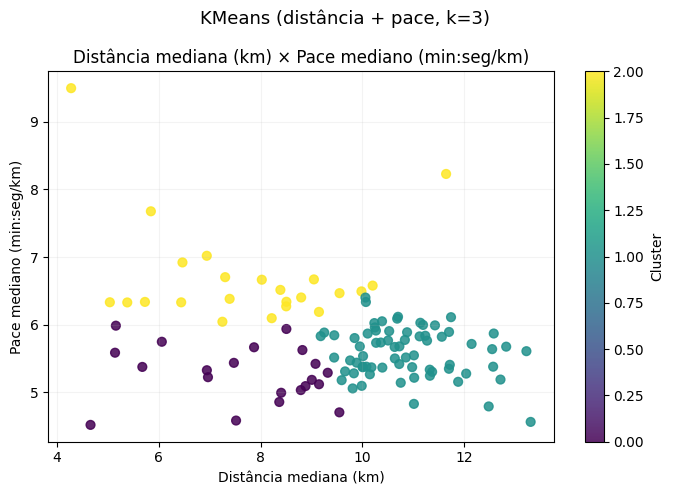


2. FC + distância
Features: ['average heart rate (bpm)', 'distance (m)']
Inércia: 99.718
Silhouette: 0.4758
Davies-Bouldin: 0.7282
Calinski-Harabasz: 71.3979
Atletas clusterizados: 114
Contagem por cluster:
shape: (3, 2)
┌──────────────────┬─────────┐
│ cluster_corredor ┆ atletas │
│ ---              ┆ ---     │
│ i32              ┆ u32     │
╞══════════════════╪═════════╡
│ 0                ┆ 11      │
│ 1                ┆ 78      │
│ 2                ┆ 25      │
└──────────────────┴─────────┘
Centros (escala original):
  cluster_0: fc=162.7 bpm | dist=9.46 km
  cluster_1: fc=147.4 bpm | dist=10.58 km
  cluster_2: fc=148.9 bpm | dist=6.77 km


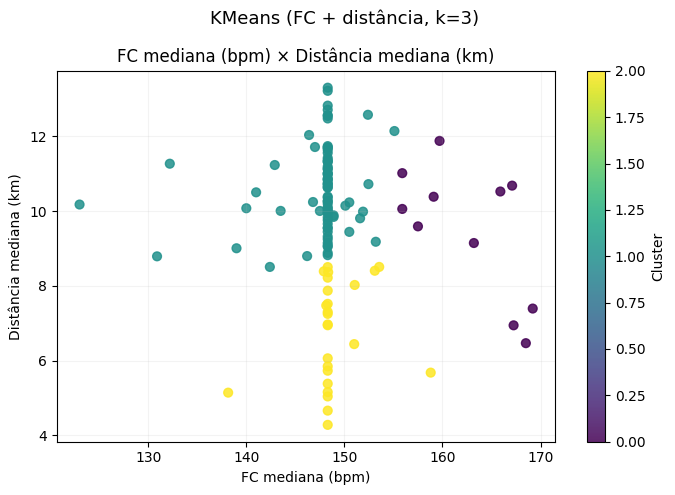


3. Distância + frequência semanal
Features: ['distance (m)', 'frequencia_semana']
Inércia: 81.2448
Silhouette: 0.4509
Davies-Bouldin: 0.7819
Calinski-Harabasz: 100.2515
Atletas clusterizados: 114
Contagem por cluster:
shape: (3, 2)
┌──────────────────┬─────────┐
│ cluster_corredor ┆ atletas │
│ ---              ┆ ---     │
│ i32              ┆ u32     │
╞══════════════════╪═════════╡
│ 0                ┆ 24      │
│ 1                ┆ 76      │
│ 2                ┆ 14      │
└──────────────────┴─────────┘
Centros (escala original):
  cluster_0: dist=6.61 km | freq=1.03 corridas/semana
  cluster_1: dist=10.39 km | freq=1.93 corridas/semana
  cluster_2: dist=10.71 km | freq=4.29 corridas/semana


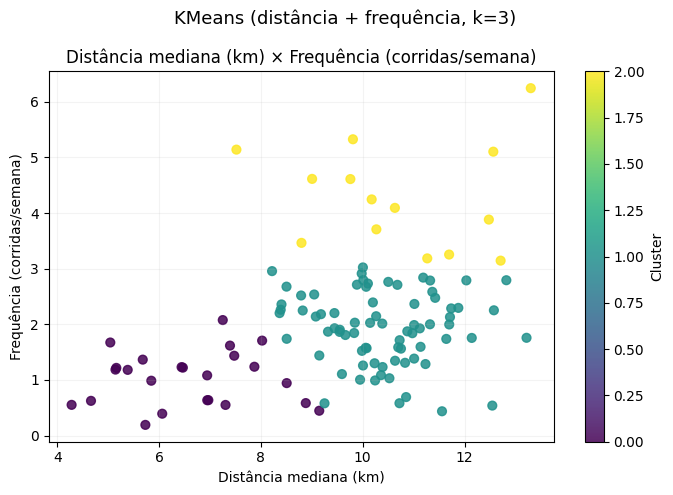

In [4]:
COMBINACOES = {
    "distancia_pace": {
        "titulo": "1. Distância + pace",
        "features": [COL_DISTANCE, COL_PACE],
    },
    "fc_distancia": {
        "titulo": "2. FC + distância",
        "features": [COL_HR, COL_DISTANCE],
    },
    "distancia_frequencia": {
        "titulo": "3. Distância + frequência semanal",
        "features": [COL_DISTANCE, COL_FREQUENCIA],
    },
}

resultados = {}
for chave, cfg in COMBINACOES.items():
    print(f"\n{'=' * 60}")
    print(cfg["titulo"])
    print('=' * 60)
    resultados[chave] = treina_kmeans(
        df,
        features=cfg["features"],
        n_clusters=3,
        plotar=True,
        verbose=True,
    )


In [5]:
LABELS_EXIBIR = {
    COL_DISTANCE: "distancia_km",
    COL_PACE: "pace",
    COL_HR: "fc_bpm",
    COL_FREQUENCIA: "freq_semana",
}

resumo_comparativo = []
centros_por_combinacao = []

for chave, cfg in COMBINACOES.items():
    r = resultados[chave]
    contagem = r.detalhes["contagem_clusters"]
    atletas_por_cluster = [c["atletas"] for c in contagem]
    resumo_comparativo.append({
        "combinacao": cfg["titulo"],
        "silhouette": round(r.metricas["silhouette"], 4),
        "inercia": round(r.metricas["inercia"], 4),
        "atletas": r.df_exibir.height,
        "min_cluster": min(atletas_por_cluster),
        "max_cluster": max(atletas_por_cluster),
    })

    for nome, centro in r.detalhes["centros"].items():
        linha = {"combinacao": cfg["titulo"], "cluster": nome}
        for col in cfg["features"]:
            valor = centro[col]
            if col == COL_DISTANCE:
                linha[LABELS_EXIBIR[col]] = round(valor / 1000, 2)
            elif col == COL_PACE:
                linha[LABELS_EXIBIR[col]] = formatar_pace(valor)
            else:
                linha[LABELS_EXIBIR[col]] = round(valor, 2)
        centros_por_combinacao.append(linha)

df_resumo = pl.DataFrame(resumo_comparativo).sort("silhouette", descending=True)
print("Resumo comparativo (k=3) — ordenado por silhouette:")
display(df_resumo)
print("\nCentros por combinação (pace em min:seg/km):")
display(pl.DataFrame(centros_por_combinacao))


Resumo comparativo (k=3) — ordenado por silhouette:


combinacao,silhouette,inercia,atletas,min_cluster,max_cluster
str,f64,f64,i64,i64,i64
"""2. FC + distância""",0.4758,99.718,114,11,78
"""3. Distância + frequência sema…",0.4509,81.2448,114,14,76
"""1. Distância + pace""",0.3947,101.9799,114,21,70



Centros por combinação (pace em min:seg/km):


combinacao,cluster,distancia_km,pace,fc_bpm,freq_semana
str,str,f64,str,f64,f64
"""1. Distância + pace""","""cluster_0""",7.68,"""5:16/km""",null,null
"""1. Distância + pace""","""cluster_1""",10.84,"""5:35/km""",null,null
"""1. Distância + pace""","""cluster_2""",7.74,"""6:43/km""",null,null
"""2. FC + distância""","""cluster_0""",9.46,null,162.66,null
"""2. FC + distância""","""cluster_1""",10.58,null,147.36,null
"""2. FC + distância""","""cluster_2""",6.77,null,148.91,null
"""3. Distância + frequência sema…","""cluster_0""",6.61,null,null,1.03
"""3. Distância + frequência sema…","""cluster_1""",10.39,null,null,1.93
"""3. Distância + frequência sema…","""cluster_2""",10.71,null,null,4.29


## Combinação escolhida

**Recomendação: Distância + pace** (`distancia_pace`).

Na **comparação inicial**, testamos k=3 **sem** separar gênero (3 clusters no total).

Na **análise detalhada**, adicionamos a coluna **`gender`** e clusterizamos
**homens e mulheres separadamente** — após escolher k por silhouette (próxima seção),
usamos **k=2 para cada gênero → 4 categorias** (`C0-M`, `C1-M`, `C0-F`, `C1-F`).

> Pace exibido em **min:seg/km** (ex.: 6:40/km).

In [6]:
COMBINACAO_ESCOLHIDA = "distancia_pace"
K_POR_GENERO = 2

cfg = COMBINACOES[COMBINACAO_ESCOLHIDA]

print("Comparação inicial (referência, sem separar gênero):")
ref = resultados[COMBINACAO_ESCOLHIDA]
print(f"  Silhouette: {ref.metricas['silhouette']:.4f} | clusters: 3")


Comparação inicial (referência, sem separar gênero):
  Silhouette: 0.3947 | clusters: 3


## Escolha de k (por gênero)

Antes de clusterizar, testamos **k de 2 a 7** com curva de silhouette **separadamente** em masculino e feminino — para justificar **k=2** (4 categorias finais).


Silhouette por k — clusterização separada por gênero:


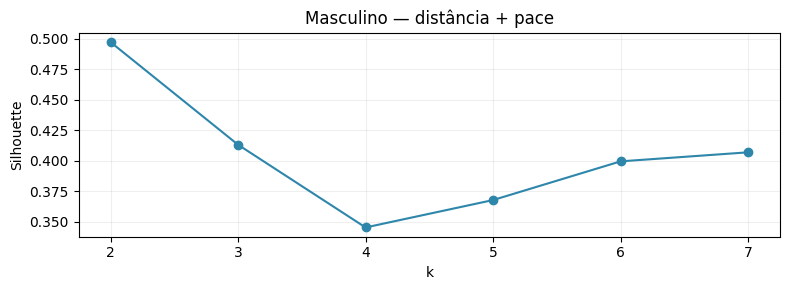

k,silhouette
i64,f64
2,0.497374
3,0.413197
4,0.345354
5,0.367833
6,0.399567
7,0.40698


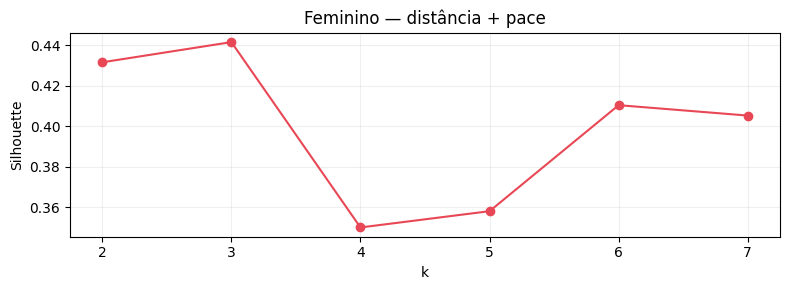

k,silhouette
i64,f64
2,0.431607
3,0.441579
4,0.350072
5,0.358109
6,0.410437
7,0.405312


In [7]:
ks = range(2, 8)

print("Silhouette por k — clusterização separada por gênero:")
for genero in ["M", "F"]:
    sils = []
    rotulo = "Masculino" if genero == "M" else "Feminino"
    df_genero = df.filter(pl.col(COL_GENDER).str.to_uppercase() == genero)
    for k in ks:
        r = treina_kmeans(df_genero, features=cfg["features"], n_clusters=k, plotar=False, verbose=False)
        sils.append(r.metricas["silhouette"])
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.plot(list(ks), sils, marker="o", color="#2E86AB" if genero == "M" else "#E84855")
    ax.set_title(f"{rotulo} — distância + pace")
    ax.set_xlabel("k")
    ax.set_ylabel("Silhouette")
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()
    display(pl.DataFrame({"k": list(ks), "silhouette": sils}))



Análise detalhada — 1. Distância + pace + gênero (4 categorias):
Features: ['distance (m)', 'pace_min_km']
Separação: masculino e feminino clusterizados separadamente
Categorias geradas: 4 (k=2 por gênero)
Inércia total: 138.9821
Silhouette média ponderada: 0.4801
Atletas clusterizados: 114

Métricas por gênero:
  Masculino: 84 atletas | k=2 | silhouette=0.4974 | inercia=107.2297 | db=1.0200 | ch=46.5
  Feminino: 30 atletas | k=2 | silhouette=0.4316 | inercia=31.7524 | db=0.8813 | ch=24.9

Contagem por categoria:
shape: (4, 4)
┌───────────┬────────┬─────────┬─────────┐
│ categoria ┆ genero ┆ cluster ┆ atletas │
│ ---       ┆ ---    ┆ ---     ┆ ---     │
│ str       ┆ str    ┆ i64     ┆ i64     │
╞═══════════╪════════╪═════════╪═════════╡
│ C0-M      ┆ M      ┆ 0       ┆ 68      │
│ C1-M      ┆ M      ┆ 1       ┆ 16      │
│ C0-F      ┆ F      ┆ 0       ┆ 18      │
│ C1-F      ┆ F      ┆ 1       ┆ 12      │
└───────────┴────────┴─────────┴─────────┘

Centros por categoria:
  C0-F: dist

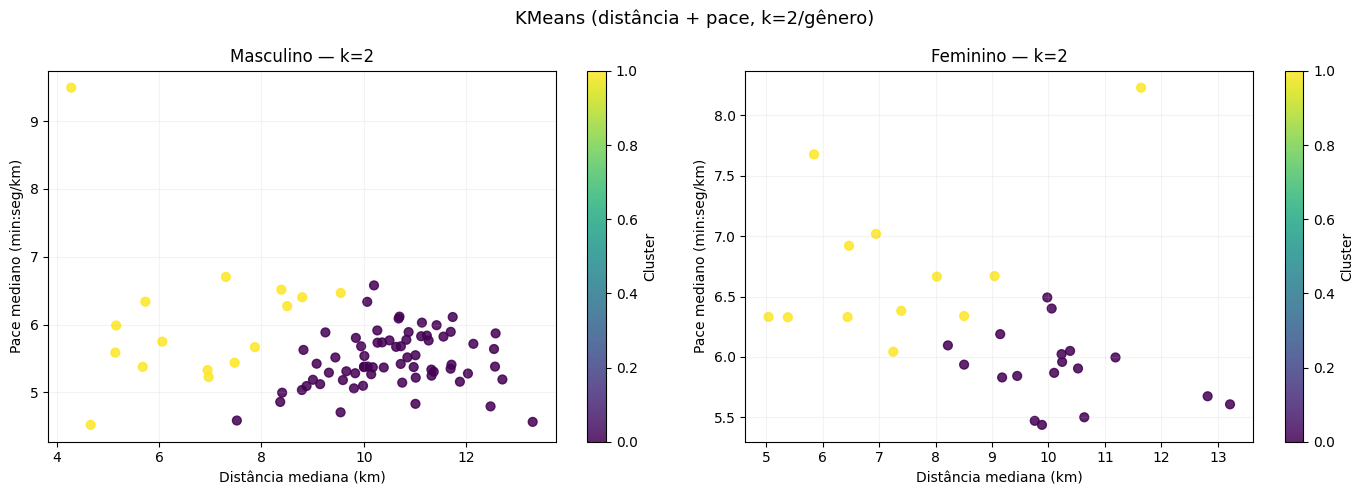

In [8]:
print(f"\nAnálise detalhada — {cfg['titulo']} + gênero (4 categorias):")
resultado = treina_kmeans_por_genero(
    df,
    features=cfg["features"],
    n_clusters=K_POR_GENERO,
    plotar=True,
    verbose=True,
)
perfil = resultado.df_exibir


## Análise detalhada — distância + pace **com gênero**

Homens e mulheres são clusterizados **em separado** (k=2 cada) → **4 categorias**.
Rankings de pace comparam atletas do mesmo gênero e cluster.

Colunas usadas: `distance (m)`, `pace_min_km` e **`gender`**.


In [9]:
resumo_categoria = (
    perfil.group_by("categoria", COL_GENDER)
    .agg(
        pl.len().alias("atletas"),
        (pl.col(COL_DISTANCE).median() / 1000).round(2).alias("dist_km_med"),
        pl.col(COL_PACE).median().alias("_pace_med"),
        pl.col(COL_FREQUENCIA).median().round(2).alias("freq_semana_med"),
    )
    .sort("categoria")
    .with_columns(
        pl.col("_pace_med").map_elements(formatar_pace, return_dtype=pl.Utf8).alias("pace_med"),
    )
    .drop("_pace_med")
)

print(f"Total de categorias: {perfil['categoria'].n_unique()}")
resumo_categoria


Total de categorias: 4


categoria,gender,atletas,dist_km_med,freq_semana_med,pace_med
str,str,u32,f64,f64,str
"""C0-F""","""F""",18,10.08,1.97,"""5:55/km"""
"""C0-M""","""M""",68,10.66,2.08,"""5:24/km"""
"""C1-F""","""F""",12,7.1,1.42,"""6:31/km"""
"""C1-M""","""M""",16,6.96,1.2,"""5:52/km"""


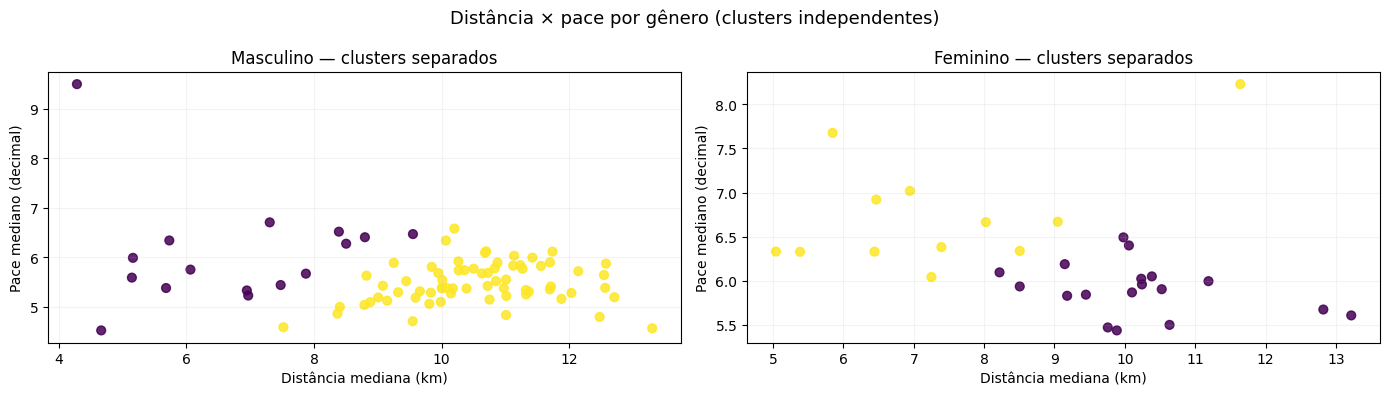

In [144]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, genero in zip(axes, ["M", "F"]):
    sub = perfil.filter(pl.col(COL_GENDER) == genero)
    titulo = "Masculino" if genero == "M" else "Feminino"
    ax.scatter(
        (sub[COL_DISTANCE] / 1000).to_numpy(),
        sub[COL_PACE].to_numpy(),
        c=sub[COL_CLUSTER_CORREDOR].to_numpy(),
        cmap="viridis",
        alpha=0.85,
        s=40,
    )
    ax.set_xlabel("Distância mediana (km)")
    ax.set_ylabel("Pace mediano (decimal)")
    ax.set_title(f"{titulo} — clusters separados")
    ax.grid(alpha=0.15)

fig.suptitle("Distância × pace por gênero (clusters independentes)", fontsize=13)
plt.tight_layout()
plt.show()


## Categorias geradas (cluster × gênero)

Cada categoria é um cluster KMeans **dentro de um gênero**.
Mulheres e homens **não competem no mesmo ranking** de pace.


In [10]:
display(resumo_categoria)

print("\nMétricas por gênero:")
for genero, m in resultado.detalhes["metricas_por_genero"].items():
    rotulo = "Masculino" if genero == "M" else "Feminino"
    print(
        f"  {rotulo}: {m['n_atletas']} atletas | k={m['k']} | "
        f"silhouette={m['silhouette']:.4f}"
    )


categoria,gender,atletas,dist_km_med,freq_semana_med,pace_med
str,str,u32,f64,f64,str
"""C0-F""","""F""",18,10.08,1.97,"""5:55/km"""
"""C0-M""","""M""",68,10.66,2.08,"""5:24/km"""
"""C1-F""","""F""",12,7.1,1.42,"""6:31/km"""
"""C1-M""","""M""",16,6.96,1.2,"""5:52/km"""



Métricas por gênero:
  Masculino: 84 atletas | k=2 | silhouette=0.4974
  Feminino: 30 atletas | k=2 | silhouette=0.4316


## Atletas por categoria — posição no pace

Para cada categoria (`C0-M`, `C1-F`, …), calculamos melhor/pior pace e o ranking
do atleta **dentro do mesmo gênero e cluster**.


In [11]:
fichas = montar_fichas_atletas(perfil)

print(f"Fichas: {fichas.height} atletas | {fichas['categoria'].n_unique()} categorias")
tabela_fichas(fichas)


Fichas: 114 atletas | 4 categorias


id,nome,genero,categoria,corridas,cluster,dist_km,pace,melhor_categoria,pior_categoria,delta_melhor,delta_pior,rank,n_categoria
i64,str,str,str,u32,i32,f64,str,str,str,str,str,u32,u32
5035018,"""Júlia Almeida""","""F""","""C0-F""",836,0,9.89,"""5:26/km""","""5:26/km""","""6:30/km""","""+0s""","""+1:03""",1,18
20181492,"""Melissa Rocha""","""F""","""C0-F""",676,0,9.76,"""5:28/km""","""5:26/km""","""6:30/km""","""+2s""","""+1:01""",2,18
19905281,"""Nicole Barbosa""","""F""","""C0-F""",169,0,10.64,"""5:30/km""","""5:26/km""","""6:30/km""","""+4s""","""+59s""",3,18
20032449,"""Tânia Queiroz""","""F""","""C0-F""",264,0,13.22,"""5:36/km""","""5:26/km""","""6:30/km""","""+10s""","""+53s""",4,18
18845906,"""Sofia Castro""","""F""","""C0-F""",431,0,12.82,"""5:40/km""","""5:26/km""","""6:30/km""","""+14s""","""+49s""",5,18
…,…,…,…,…,…,…,…,…,…,…,…,…,…
25191153,"""Thiago Rocha""","""M""","""C1-M""",447,1,8.8,"""6:24/km""","""4:31/km""","""9:30/km""","""+1:53""","""+3:06""",12,16
11284478,"""Felipe Souza""","""M""","""C1-M""",500,1,9.55,"""6:28/km""","""4:31/km""","""9:30/km""","""+1:57""","""+3:02""",13,16
23729907,"""Gustavo Lima""","""M""","""C1-M""",841,1,8.39,"""6:31/km""","""4:31/km""","""9:30/km""","""+2:00""","""+2:59""",14,16


In [12]:
for categoria in sorted(fichas["categoria"].unique().to_list()):
    subset = fichas.filter(pl.col("categoria") == categoria)
    melhor = formatar_pace(subset["pace_melhor_categoria"][0])
    pior = formatar_pace(subset["pace_pior_categoria"][0])
    print(f"\n{categoria} — melhor: {melhor} | pior: {pior} | atletas: {subset.height}")
    display(tabela_fichas(subset).head(5))



C0-F — melhor: 5:26/km | pior: 6:30/km | atletas: 18


id,nome,genero,categoria,corridas,cluster,dist_km,pace,melhor_categoria,pior_categoria,delta_melhor,delta_pior,rank,n_categoria
i64,str,str,str,u32,i32,f64,str,str,str,str,str,u32,u32
5035018,"""Júlia Almeida""","""F""","""C0-F""",836,0,9.89,"""5:26/km""","""5:26/km""","""6:30/km""","""+0s""","""+1:03""",1,18
20181492,"""Melissa Rocha""","""F""","""C0-F""",676,0,9.76,"""5:28/km""","""5:26/km""","""6:30/km""","""+2s""","""+1:01""",2,18
19905281,"""Nicole Barbosa""","""F""","""C0-F""",169,0,10.64,"""5:30/km""","""5:26/km""","""6:30/km""","""+4s""","""+59s""",3,18
20032449,"""Tânia Queiroz""","""F""","""C0-F""",264,0,13.22,"""5:36/km""","""5:26/km""","""6:30/km""","""+10s""","""+53s""",4,18
18845906,"""Sofia Castro""","""F""","""C0-F""",431,0,12.82,"""5:40/km""","""5:26/km""","""6:30/km""","""+14s""","""+49s""",5,18



C0-M — melhor: 4:34/km | pior: 6:35/km | atletas: 68


id,nome,genero,categoria,corridas,cluster,dist_km,pace,melhor_categoria,pior_categoria,delta_melhor,delta_pior,rank,n_categoria
i64,str,str,str,u32,i32,f64,str,str,str,str,str,u32,u32
13435425,"""Gilberto Pacheco""","""M""","""C0-M""",1210,0,13.3,"""4:34/km""","""4:34/km""","""6:35/km""","""+0s""","""+2:01""",1,68
27655563,"""Patrick Neves""","""M""","""C0-M""",592,0,7.52,"""4:35/km""","""4:34/km""","""6:35/km""","""+1s""","""+2:00""",2,68
8180382,"""Orlando Pires""","""M""","""C0-M""",480,0,9.55,"""4:42/km""","""4:34/km""","""6:35/km""","""+8s""","""+1:52""",3,68
7947798,"""Vitor Antunes""","""M""","""C0-M""",982,0,12.48,"""4:48/km""","""4:34/km""","""6:35/km""","""+14s""","""+1:47""",4,68
5421161,"""André Barbosa""","""M""","""C0-M""",569,0,11.01,"""4:50/km""","""4:34/km""","""6:35/km""","""+16s""","""+1:45""",5,68



C1-F — melhor: 6:03/km | pior: 8:14/km | atletas: 12


id,nome,genero,categoria,corridas,cluster,dist_km,pace,melhor_categoria,pior_categoria,delta_melhor,delta_pior,rank,n_categoria
i64,str,str,str,u32,i32,f64,str,str,str,str,str,u32,u32
25277048,"""Ingrid Siqueira""","""F""","""C1-F""",246,1,7.25,"""6:03/km""","""6:03/km""","""8:14/km""","""+0s""","""+2:11""",1,12
20557028,"""Lívia Brandão""","""F""","""C1-F""",169,1,5.38,"""6:20/km""","""6:03/km""","""8:14/km""","""+17s""","""+1:54""",2,12
15002603,"""Queila Moura""","""F""","""C1-F""",235,1,6.44,"""6:20/km""","""6:03/km""","""8:14/km""","""+17s""","""+1:54""",3,12
37580157,"""Clara Martins""","""F""","""C1-F""",88,1,5.04,"""6:20/km""","""6:03/km""","""8:14/km""","""+17s""","""+1:54""",4,12
10305317,"""Sabrina Lima""","""F""","""C1-F""",218,1,8.51,"""6:20/km""","""6:03/km""","""8:14/km""","""+18s""","""+1:53""",5,12



C1-M — melhor: 4:31/km | pior: 9:30/km | atletas: 16


id,nome,genero,categoria,corridas,cluster,dist_km,pace,melhor_categoria,pior_categoria,delta_melhor,delta_pior,rank,n_categoria
i64,str,str,str,u32,i32,f64,str,str,str,str,str,u32,u32
26363316,"""Otto Seabra""","""M""","""C1-M""",64,1,4.66,"""4:31/km""","""4:31/km""","""9:30/km""","""+0s""","""+4:59""",1,16
30414122,"""Hélio Crispim""","""M""","""C1-M""",43,1,6.97,"""5:13/km""","""4:31/km""","""9:30/km""","""+42s""","""+4:16""",2,16
6583234,"""Fabrício Guedes""","""M""","""C1-M""",664,1,6.95,"""5:20/km""","""4:31/km""","""9:30/km""","""+48s""","""+4:10""",3,16
38870390,"""Daniel Cunha""","""M""","""C1-M""",8,1,5.68,"""5:23/km""","""4:31/km""","""9:30/km""","""+51s""","""+4:07""",4,16
32507764,"""Geraldo Passos""","""M""","""C1-M""",112,1,7.48,"""5:26/km""","""4:31/km""","""9:30/km""","""+55s""","""+4:04""",5,16


## Fichas visuais

A barra indica a posição do atleta no pace da **categoria** (cluster + gênero):
esquerda = melhor pace, direita = pior pace.


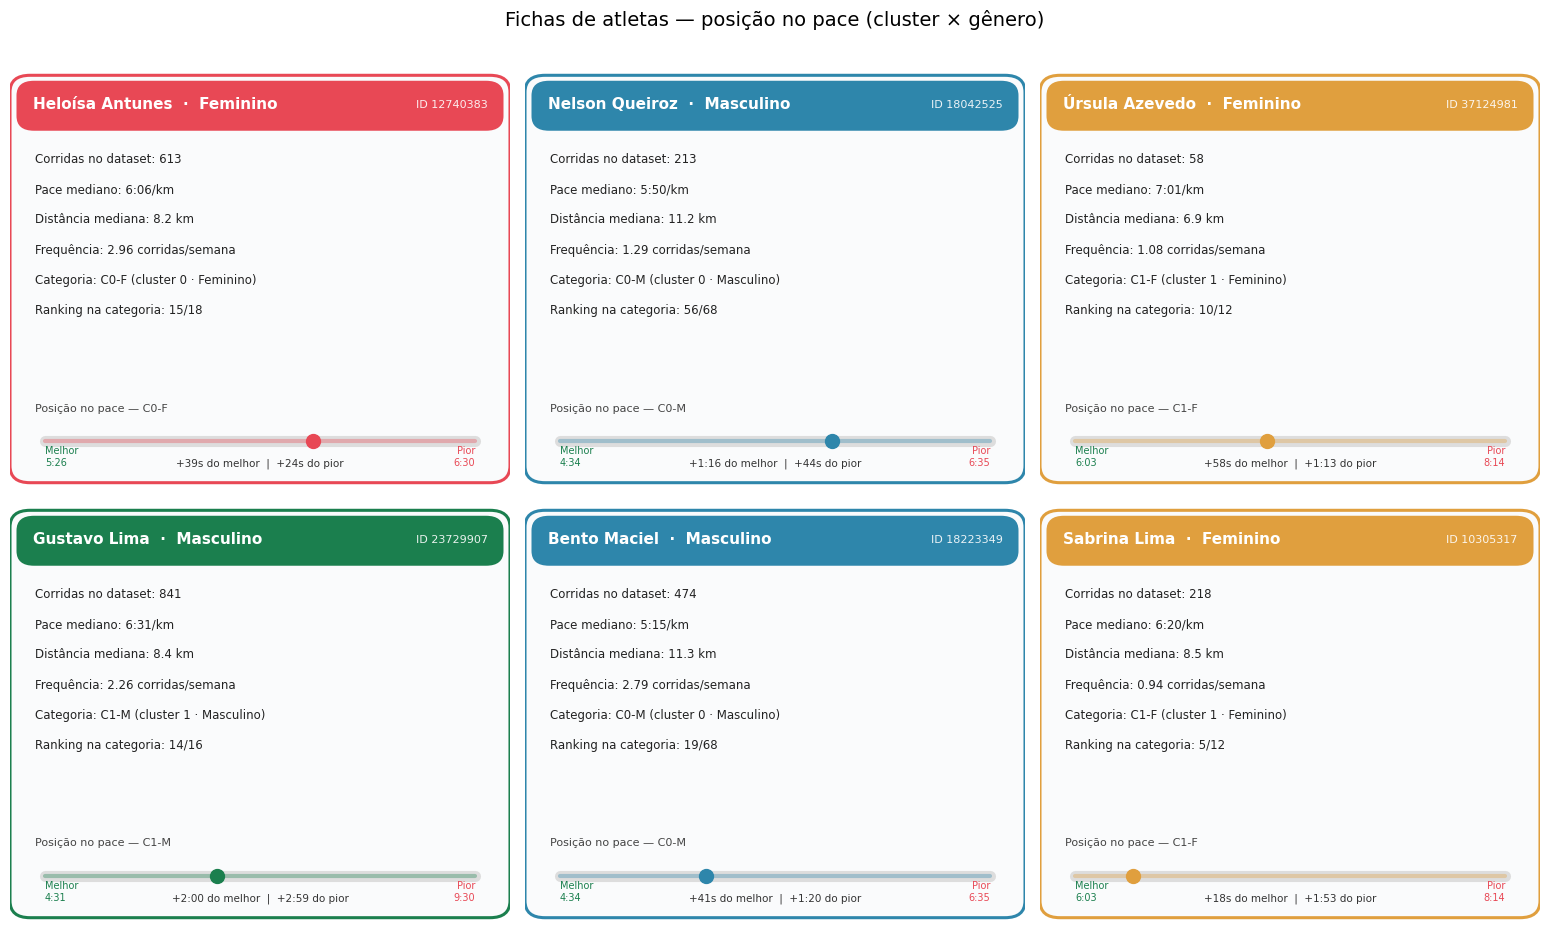

In [13]:
fig = plotar_fichas_atletas(fichas, n=6, seed=42)
plt.show()


### Ficha individual

Troque o `athlete_id` para inspecionar um corredor específico.


Atleta: Júlia Almeida (ID 5035018)
  Categoria: C0-F
  Pace: 5:26/km
  Melhor da categoria: 5:26/km (+0s do melhor)
  Pior da categoria: 6:30/km (+1:03 do pior)
  Ranking: 1/18


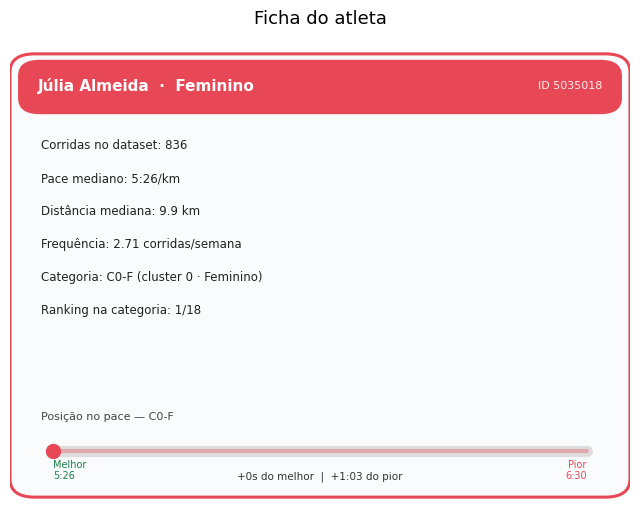

In [14]:
athlete_id = fichas[COL_ATHLETE][0]
linha = fichas.filter(pl.col(COL_ATHLETE) == athlete_id).row(0, named=True)

print(f"Atleta: {linha['nome_ficticio']} (ID {athlete_id})")
print(f"  Categoria: {linha['categoria']}")
print(f"  Pace: {formatar_pace(linha[COL_PACE])}")
print(f"  Melhor da categoria: {formatar_pace(linha['pace_melhor_categoria'])} ({formatar_delta_pace(linha['dist_pace_melhor'])} do melhor)")
print(f"  Pior da categoria: {formatar_pace(linha['pace_pior_categoria'])} ({formatar_delta_pace(linha['dist_pace_pior'])} do pior)")
print(f"  Ranking: {int(linha['ranking_na_categoria'])}/{int(linha['atletas_na_categoria'])}")

fig = plotar_ficha_atleta(fichas, athlete_id)
plt.show()


## Validação de clusters

Consolidamos aqui todas as métricas de qualidade do agrupamento KMeans final (`distância + pace`, k=2 por gênero).

| Tipo | Métricas | Objetivo |
|------|----------|----------|
| **Interna** | Silhouette, Davies-Bouldin, Calinski-Harabasz | Coesão e separação dos clusters |
| **Estabilidade** | ARI entre execuções | Robustez do agrupamento |
| **Grid de k** | Curvas por gênero (k=2..7) | Justificar a escolha de k |
| **Externa** | ARI, NMI, homogeneidade, completude, V-measure | Concordância com perfis por regras |
| **Diagnóstico** | Silhouette por amostra | Atletas na fronteira entre clusters |


VALIDAÇÃO INTERNA

Masculino (84 atletas, k=2):
  Silhouette:        0.4974
  Davies-Bouldin:    1.0199782906464374
  Calinski-Harabasz: 46.47186357391357
  Tamanho clusters:  min=16 | max=68

Feminino (30 atletas, k=2):
  Silhouette:        0.4316
  Davies-Bouldin:    0.8813066462563519
  Calinski-Harabasz: 24.909331221404848
  Tamanho clusters:  min=12 | max=18

ESTABILIDADE (ARI entre execuções consecutivas)
  Masculino: ARI = 1.0000 ± 0.0000 (19 runs)
  Feminino: ARI = 0.9930 ± 0.0298 (19 runs)

GRID DE k — métricas internas por gênero

Masculino:


k,silhouette,davies_bouldin,calinski_harabasz,min_cluster,max_cluster
i64,f64,f64,f64,i64,i64
2,0.497374,1.019978,46.471864,16,68
3,0.413197,0.754364,54.162826,1,60
4,0.346639,0.747279,60.967748,1,42
5,0.367833,0.685276,69.837375,1,27
6,0.399567,0.653643,80.535469,1,24
7,0.408739,0.684766,81.48153,1,25


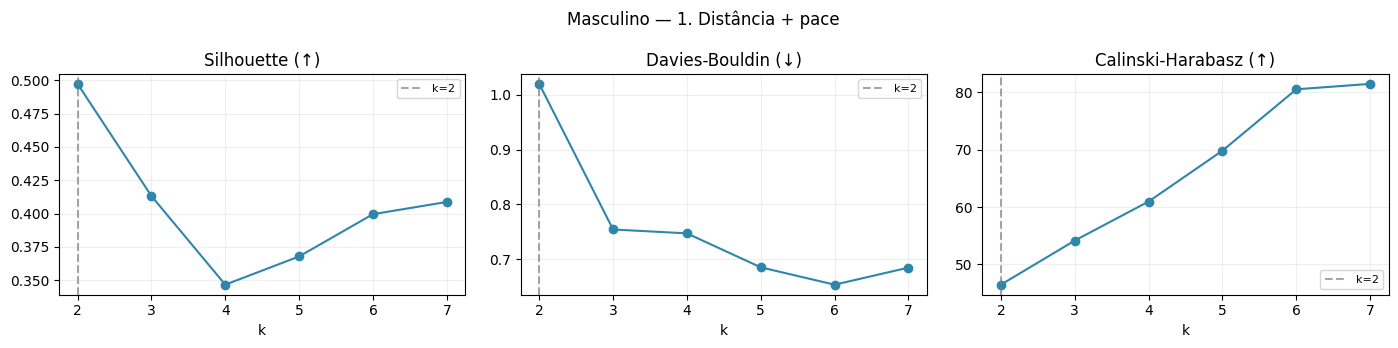


Feminino:


k,silhouette,davies_bouldin,calinski_harabasz,min_cluster,max_cluster
i64,f64,f64,f64,i64,i64
2,0.431607,0.881307,24.909331,12,18
3,0.441579,0.586242,26.466836,1,18
4,0.320052,0.782608,26.077068,1,14
5,0.386353,0.659185,29.498062,1,11
6,0.410772,0.620189,36.747665,1,11
7,0.412036,0.599103,36.863851,1,8


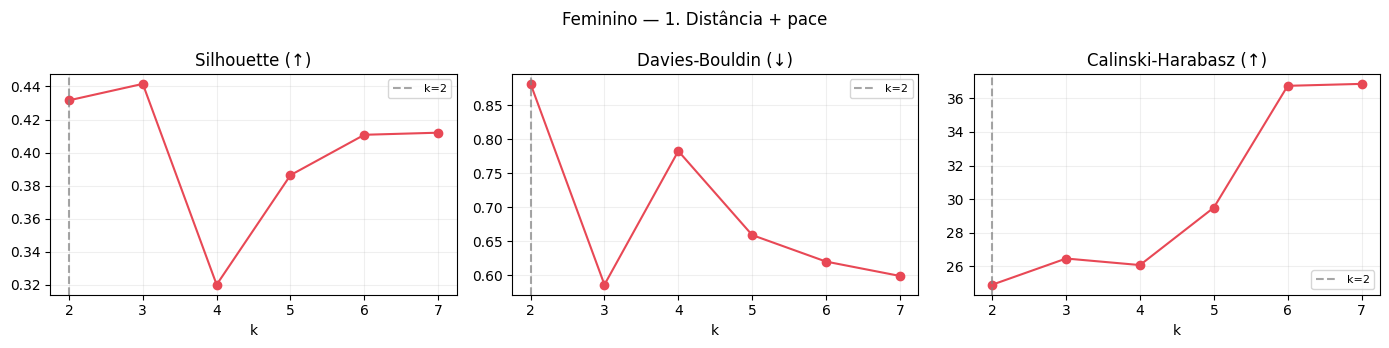

In [15]:
from dataset.categorizar.perfil_atletas import montar_perfil_atletas
from dataset.categorizar.validacao_cluster import (
    avaliar_k,
    silhouette_por_amostra,
    validar_resultado_kmeans,
)
from dataset.constants import (
    COL_NIVEL_DISTANCIA,
    COL_NIVEL_PACE,
    COL_NIVEL_VOLUME,
    COL_PERFIL_ATLETA,
)

resultado = validar_resultado_kmeans(
    resultado,
    df=df,
    features=cfg["features"],
)

print("=" * 60)
print("VALIDAÇÃO INTERNA")
print("=" * 60)
for grupo, m in resultado.detalhes["validacao_interna"].items():
    print(
        f"\n{grupo} ({m['n_atletas']} atletas, k={m['k']}):\n"
        f"  Silhouette:        {m['silhouette']:.4f}\n"
        f"  Davies-Bouldin:    {m.get('davies_bouldin', '—')}\n"
        f"  Calinski-Harabasz: {m.get('calinski_harabasz', '—')}\n"
        f"  Tamanho clusters:  min={m['min_cluster']} | max={m['max_cluster']}"
    )

print("\n" + "=" * 60)
print("ESTABILIDADE (ARI entre execuções consecutivas)")
print("=" * 60)
for grupo, m in resultado.detalhes["validacao_estabilidade"].items():
    print(f"  {grupo}: ARI = {m['ari_medio']:.4f} ± {m['ari_std']:.4f} ({int(m['n_runs'])} runs)")

print("\n" + "=" * 60)
print("GRID DE k — métricas internas por gênero")
print("=" * 60)
perfil_base = montar_perfil_atletas(df)
ks = range(2, 8)
grids = {}
for genero in ["M", "F"]:
    rotulo = "Masculino" if genero == "M" else "Feminino"
    subset = perfil_base.filter(pl.col(COL_GENDER).str.to_uppercase() == genero)
    grid = avaliar_k(subset, cfg["features"], ks=ks)
    grids[genero] = grid
    print(f"\n{rotulo}:")
    display(grid)

    fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
    cor = "#2E86AB" if genero == "M" else "#E84855"
    for ax, col, titulo in zip(
        axes,
        ["silhouette", "davies_bouldin", "calinski_harabasz"],
        ["Silhouette (↑)", "Davies-Bouldin (↓)", "Calinski-Harabasz (↑)"],
    ):
        ax.plot(grid["k"], grid[col], marker="o", color=cor)
        ax.axvline(K_POR_GENERO, ls="--", color="gray", alpha=0.7, label=f"k={K_POR_GENERO}")
        ax.set_title(titulo)
        ax.set_xlabel("k")
        ax.grid(alpha=0.2)
        ax.legend(fontsize=8)
    fig.suptitle(f"{rotulo} — {cfg['titulo']}", fontsize=12)
    plt.tight_layout()
    plt.show()


In [16]:
from dataset.categorizar.validacao_cluster import comparar_com_perfil_regras
from dataset.constants import (
    COL_NIVEL_DISTANCIA,
    COL_NIVEL_PACE,
    COL_NIVEL_VOLUME,
    COL_PERFIL_ATLETA,
)

print("=" * 60)
print("VALIDAÇÃO EXTERNA — concordância com perfis por regras")
print("=" * 60)

refs = [COL_PERFIL_ATLETA, COL_NIVEL_PACE, COL_NIVEL_VOLUME, COL_NIVEL_DISTANCIA]
externa = comparar_com_perfil_regras(resultado, df, referencias=refs)

resumo_ext = []
for ref in refs:
    vals = externa["metricas_externas"][ref]
    resumo_ext.append({
        "referencia": ref,
        "ari": round(vals["ari"], 4),
        "nmi": round(vals["nmi"], 4),
        "homogeneidade": round(vals["homogeneity"], 4),
        "completude": round(vals["completeness"], 4),
        "v_measure": round(vals["v_measure"], 4),
    })
display(pl.DataFrame(resumo_ext))

for ref in refs:
    print(f"\nContingência: categoria × {ref}")
    display(externa["contingencias"][ref])

if externa["metricas_externas_por_genero"]:
    print("\n" + "=" * 60)
    print("VALIDAÇÃO EXTERNA POR GÊNERO")
    print("=" * 60)
    for genero, metricas in externa["metricas_externas_por_genero"].items():
        rotulo = "Masculino" if genero == "M" else "Feminino"
        print(f"\n{rotulo}:")
        linhas = [
            {"referencia": ref, **{k: round(v, 4) for k, v in vals.items()}}
            for ref, vals in metricas.items()
        ]
        display(pl.DataFrame(linhas))


VALIDAÇÃO EXTERNA — concordância com perfis por regras


referencia,ari,nmi,homogeneidade,completude,v_measure
str,f64,f64,f64,f64,f64
"""perfil_atleta""",0.0259,0.1821,0.2261,0.1525,0.1821
"""nivel_pace""",0.1505,0.2395,0.2382,0.2408,0.2395
"""nivel_volume""",0.0275,0.0771,0.0821,0.0728,0.0771
"""nivel_distancia""",0.2658,0.2905,0.3618,0.2427,0.2905



Contingência: categoria × perfil_atleta


perfil_atleta,C0-F,C0-M,C1-F,C1-M,total
str,i64,i64,i64,i64,i64
"""avancado""",0,10,0,0,10
"""fundista""",2,4,0,0,6
"""iniciante""",0,0,5,2,7
"""intermediario""",16,54,7,11,88



Contingência: categoria × nivel_pace


...

nivel_distancia,C0-F,C0-M,C1-F,C1-M,total
str,i64,i64,i64,i64,i64
"""curta""",0,1,8,9,18
"""longa""",2,8,0,0,10
"""media""",16,59,4,4,83



VALIDAÇÃO EXTERNA POR GÊNERO

Feminino:


referencia,ari,nmi,homogeneity,completeness,v_measure
str,f64,f64,f64,f64,f64
"""perfil_atleta""",0.1758,0.2978,0.2957,0.3,0.2978
"""nivel_pace""",0.0792,0.2678,0.2892,0.2492,0.2678
"""nivel_volume""",0.0118,0.0527,0.0488,0.0572,0.0527
"""nivel_distancia""",0.4115,0.4598,0.4225,0.5043,0.4598



Masculino:


referencia,ari,nmi,homogeneity,completeness,v_measure
str,f64,f64,f64,f64,f64
"""perfil_atleta""",-0.0177,0.1356,0.1121,0.1717,0.1356
"""nivel_pace""",0.0715,0.0591,0.0421,0.0992,0.0591
"""nivel_volume""",0.0883,0.0912,0.0657,0.1491,0.0912
"""nivel_distancia""",0.4288,0.3855,0.3172,0.4913,0.3855


In [17]:
print("=" * 60)
print("DIAGNÓSTICO — silhouette por amostra")
print("=" * 60)
print("Valores negativos indicam atletas mais próximos de outro cluster.")

sil_amostras = silhouette_por_amostra(perfil, features=cfg["features"])

print("\nPiores 10 (fronteira entre clusters):")
display(sil_amostras.head(10))

print("\nMelhores 5 (bem definidos no cluster):")
display(sil_amostras.sort("silhouette_amostra", descending=True).head(5))

negativos = sil_amostras.filter(pl.col("silhouette_amostra") < 0).height
print(f"\nAtletas com silhouette negativo: {negativos} / {sil_amostras.height}")


DIAGNÓSTICO — silhouette por amostra
Valores negativos indicam atletas mais próximos de outro cluster.

Piores 10 (fronteira entre clusters):


athlete,cluster_corredor,gender,categoria,silhouette_amostra
i64,i32,str,str,f64
11284478,1,"""M""","""C1-M""",-0.168634
5861500,1,"""M""","""C1-M""",-0.093263
12740383,0,"""F""","""C0-F""",-0.078982
32507764,1,"""M""","""C1-M""",-0.065974
30414122,1,"""M""","""C1-M""",-0.014548
22972731,1,"""F""","""C1-F""",0.017185
6583234,1,"""M""","""C1-M""",0.03473
25191153,1,"""M""","""C1-M""",0.037278
27279222,1,"""M""","""C1-M""",0.058334



Melhores 5 (bem definidos no cluster):


athlete,cluster_corredor,gender,categoria,silhouette_amostra
i64,i32,str,str,f64
2013538,0,"""M""","""C0-M""",0.698078
17639804,0,"""M""","""C0-M""",0.696497
7191483,0,"""M""","""C0-M""",0.695092
19905281,0,"""F""","""C0-F""",0.694845
2138770,0,"""M""","""C0-M""",0.693235



Atletas com silhouette negativo: 5 / 114
